In [1]:
import numpy as np
import pandas as pd
import pickle

import sklearn
import sklearn.preprocessing
import sklearn.model_selection

import torch
import torch.nn as nn
import torch.nn.functional as F

from tqdm import tqdm
import time

from matplotlib import pyplot as plt
import os
from copy import deepcopy

from models import *

In [2]:
with open('data/current.pkl', 'rb') as file:
    df_current = pickle.load(file)

with open('data/parameters.pkl', 'rb') as file:
    df_params = pickle.load(file)

In [3]:
df_params = df_params.rename(columns={"membrane": "diaphragm", "WW": "circuit function", "nominal width": "nominal width in mm", "voltage": "voltage in V", "pvor": "p_supply in bar", "prueck": "p_back in bar"})
df_params['nominal width in mm'] = df_params['nominal width in mm'].str.replace(',', '.').astype('float')
df_params['voltage in V'] = df_params['voltage in V'].astype('float')
df_params['p_supply in bar'] = df_params['p_supply in bar'].astype('float')
df_params['p_back in bar'] = df_params['p_back in bar'].astype('float')
df_params['ID'] = df_params['ID'].astype('int')

In [4]:
X = df_current.values
y = df_params['diaphragm'].copy()

In [5]:
enc = sklearn.preprocessing.OneHotEncoder(categories=[['AA', 'FF', 'CC']], sparse=False)
y_ohe = enc.fit_transform(y.values.reshape(-1, 1))
y_ohe

array([[0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       ...,
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.]])

In [6]:
# Random Train-test split
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(X, y_ohe, test_size=0.2, random_state=42)#, stratify=y_ohe)

In [7]:
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device("cpu")

In [8]:
cat_weights = torch.tensor([1.,4.,1.],dtype=torch.float32, device=device)

In [9]:
model = PDEInspiredModel(ts_model=Upsampling,model_channels=4)
model = model.to(device)
model(torch.tensor(X_train[:1],dtype=torch.float32, device=device))

tensor([[0.3942, 0.3880, 0.2178]], grad_fn=<SoftmaxBackward0>)

In [10]:
X_fit, X_val, y_fit, y_val = sklearn.model_selection.train_test_split(X_train, y_train, test_size=0.30, random_state=123)#, stratify=y_ohe)

history = model.fit(X_fit, y_fit, X_val, y_val, cat_weights=cat_weights)

parameter count: 119

saving model

9.205299633663344e-09
epoch 0, loss=1.5875943303108215, val. loss=1.4802387952804565, val. acc.=0.1059730276465416, time: 41ms
0.0
epoch 1, loss=1.5513921976089478, val. loss=1.4579578638076782, val. acc.=0.1059730276465416, time: 12ms

saving model

1.1489824203181342e-08
epoch 2, loss=1.5341736674308777, val. loss=1.4633408784866333, val. acc.=0.4566473960876465, time: 13ms

saving model

3.01989473427966e-08
epoch 3, loss=1.5474909543991089, val. loss=1.46249258518219, val. acc.=0.4643545150756836, time: 14ms
2.4632619499698194e-08
epoch 4, loss=1.529533565044403, val. loss=1.4599131345748901, val. acc.=0.1059730276465416, time: 12ms
5.36352162683329e-09
epoch 5, loss=1.519131362438202, val. loss=1.4559608697891235, val. acc.=0.1059730276465416, time: 12ms
3.936531101089713e-08
epoch 6, loss=1.5179319381713867, val. loss=1.450972080230713, val. acc.=0.1059730276465416, time: 14ms
4.241143614081011e-08
epoch 7, loss=1.5191508531570435, val. loss=1.

epoch 64, loss=0.8010262846946716, val. loss=0.7373573780059814, val. acc.=0.8150289058685303, time: 10ms

saving model

0.00011022046783182304
epoch 65, loss=0.7736638486385345, val. loss=0.7229563593864441, val. acc.=0.8516377806663513, time: 12ms

saving model

2.51019928327878e-05
epoch 66, loss=0.765043169260025, val. loss=0.7118667960166931, val. acc.=0.863198459148407, time: 11ms
2.0645840777433477e-05
epoch 67, loss=0.7738989889621735, val. loss=0.709471583366394, val. acc.=0.8015414476394653, time: 9ms
3.9004171412670985e-05
epoch 68, loss=0.7455855011940002, val. loss=0.7039775848388672, val. acc.=0.7880539298057556, time: 11ms
1.8031920262728818e-05
epoch 69, loss=0.7502620220184326, val. loss=0.6927064657211304, val. acc.=0.7976878881454468, time: 13ms

saving model

6.431544989027316e-06
epoch 70, loss=0.7266019284725189, val. loss=0.6718567609786987, val. acc.=0.8805394768714905, time: 13ms

saving model

2.3756359951221384e-05
epoch 71, loss=0.7203648388385773, val. loss

0.0010713734955061227
epoch 131, loss=0.36866991221904755, val. loss=0.33902812004089355, val. acc.=0.9152215719223022, time: 10ms
0.0001960318913916126
epoch 132, loss=0.3527805507183075, val. loss=0.33634093403816223, val. acc.=0.9152215719223022, time: 11ms
9.132461127592251e-05
epoch 133, loss=0.3567695915699005, val. loss=0.32111576199531555, val. acc.=0.9556840062141418, time: 10ms
0.00025537575129419565
epoch 134, loss=0.37204715609550476, val. loss=0.34431344270706177, val. acc.=0.9017341136932373, time: 9ms
0.00019610492745414376
epoch 135, loss=0.37541717290878296, val. loss=0.321932852268219, val. acc.=0.9287090301513672, time: 9ms
0.00048382820386905223
epoch 136, loss=0.35765478014945984, val. loss=0.3142845928668976, val. acc.=0.9556840062141418, time: 9ms
0.0003383643488632515
epoch 137, loss=0.34426863491535187, val. loss=0.33365368843078613, val. acc.=0.9055876731872559, time: 9ms
0.000657940108794719
epoch 138, loss=0.3491273522377014, val. loss=0.3198665678501129, va

0.0011001656530424953
epoch 212, loss=0.2627830356359482, val. loss=0.23168228566646576, val. acc.=0.9306358098983765, time: 11ms
0.00020263013720978051
epoch 213, loss=0.25705310702323914, val. loss=0.22086942195892334, val. acc.=0.9518304467201233, time: 10ms
0.0008034986967686564
epoch 214, loss=0.2554818168282509, val. loss=0.21773995459079742, val. acc.=0.9537572264671326, time: 9ms
0.0006631204742006958
epoch 215, loss=0.25875598192214966, val. loss=0.2272186577320099, val. acc.=0.9325626492500305, time: 9ms
0.0035386831732466817
epoch 216, loss=0.25406263023614883, val. loss=0.21947906911373138, val. acc.=0.9518304467201233, time: 9ms
0.0014883952680975199
epoch 217, loss=0.2583260089159012, val. loss=0.2221279889345169, val. acc.=0.949903666973114, time: 9ms
0.0005001449608244002
epoch 218, loss=0.23776064068078995, val. loss=0.22208191454410553, val. acc.=0.949903666973114, time: 10ms
0.0014851657906547189
epoch 219, loss=0.2624397426843643, val. loss=0.22268962860107422, val.

0.0004750681255245581
epoch 284, loss=0.2212579846382141, val. loss=0.18893535435199738, val. acc.=0.9576107859611511, time: 9ms
0.001266905528609641
epoch 285, loss=0.21203888952732086, val. loss=0.19381679594516754, val. acc.=0.9460501074790955, time: 11ms
0.0002165656624129042
epoch 286, loss=0.20606210827827454, val. loss=0.18497774004936218, val. acc.=0.963391125202179, time: 10ms
0.0008540475973859429
epoch 287, loss=0.20969221740961075, val. loss=0.18303091824054718, val. acc.=0.9614643454551697, time: 10ms
0.0009628715924918652
epoch 288, loss=0.22119425237178802, val. loss=0.20575545728206635, val. acc.=0.9248554706573486, time: 9ms
0.0
epoch 289, loss=0.23034419119358063, val. loss=0.18493863940238953, val. acc.=0.9556840062141418, time: 9ms
0.003477351914625615
epoch 290, loss=0.22344230115413666, val. loss=0.17954622209072113, val. acc.=0.963391125202179, time: 9ms
0.0009268986468669027
epoch 291, loss=0.20480330288410187, val. loss=0.19760969281196594, val. acc.=0.94026976

...

0.20198393613100052
epoch 9727, loss=0.05067627690732479, val. loss=0.19503356516361237, val. acc.=0.9691714644432068, time: 13ms
0.03858070820569992
epoch 9728, loss=0.05685836635529995, val. loss=0.19656427204608917, val. acc.=0.9730250239372253, time: 12ms
0.09165395796298981
epoch 9729, loss=0.05260097049176693, val. loss=0.19887331128120422, val. acc.=0.9768785834312439, time: 11ms
0.34338635206222534
epoch 9730, loss=0.057522090151906013, val. loss=0.20043064653873444, val. acc.=0.9749518036842346, time: 11ms
0.2324787639081478
epoch 9731, loss=0.04645780846476555, val. loss=0.2007514387369156, val. acc.=0.9749518036842346, time: 11ms
0.07502535730600357
epoch 9732, loss=0.05012340843677521, val. loss=0.19756746292114258, val. acc.=0.9730250239372253, time: 10ms
0.23071593791246414
epoch 9733, loss=0.06838775426149368, val. loss=0.19310809671878815, val. acc.=0.9730250239372253, time: 10ms
0.05593881011009216
epoch 9734, loss=0.05719255842268467, val. loss=0.19417592883110046, va

0.295187633484602
epoch 9792, loss=0.06367228925228119, val. loss=0.2037561535835266, val. acc.=0.9672446846961975, time: 12ms
0.02283778414130211
epoch 9793, loss=0.06650041043758392, val. loss=0.19930624961853027, val. acc.=0.9768785834312439, time: 12ms
0.024107882753014565
epoch 9794, loss=0.06437635980546474, val. loss=0.19609317183494568, val. acc.=0.9749518036842346, time: 10ms
0.04494085907936096
epoch 9795, loss=0.05909452214837074, val. loss=0.19589169323444366, val. acc.=0.9749518036842346, time: 9ms
0.0
epoch 9796, loss=0.054430557414889336, val. loss=0.19826631247997284, val. acc.=0.9749518036842346, time: 10ms
0.39504867792129517
epoch 9797, loss=0.04646124877035618, val. loss=0.19979515671730042, val. acc.=0.9749518036842346, time: 9ms
0.22179245948791504
epoch 9798, loss=0.0664720181375742, val. loss=0.20087218284606934, val. acc.=0.9768785834312439, time: 10ms
0.3655942529439926
epoch 9799, loss=0.05541649088263512, val. loss=0.19861659407615662, val. acc.=0.9730250239

0.17680387198925018
epoch 9860, loss=0.04869833588600159, val. loss=0.1910659372806549, val. acc.=0.9730250239372253, time: 12ms
0.1735164225101471
epoch 9861, loss=0.061087675392627716, val. loss=0.1938776671886444, val. acc.=0.9730250239372253, time: 13ms
0.14263960346579552
epoch 9862, loss=0.06422134302556515, val. loss=0.19941051304340363, val. acc.=0.9749518036842346, time: 13ms
0.23040501400828362
epoch 9863, loss=0.054370297119021416, val. loss=0.20378944277763367, val. acc.=0.978805422782898, time: 13ms
0.29346583783626556
epoch 9864, loss=0.06314335763454437, val. loss=0.20086582005023956, val. acc.=0.9749518036842346, time: 14ms
0.11920998990535736
epoch 9865, loss=0.05219881795346737, val. loss=0.19707265496253967, val. acc.=0.9730250239372253, time: 13ms
0.06646225228905678
epoch 9866, loss=0.05712449923157692, val. loss=0.19503703713417053, val. acc.=0.9749518036842346, time: 13ms
0.11820793151855469
epoch 9867, loss=0.06516404636204243, val. loss=0.1920098066329956, val.

0.0
epoch 9925, loss=0.061237627640366554, val. loss=0.199411079287529, val. acc.=0.9749518036842346, time: 12ms
0.09576347470283508
epoch 9926, loss=0.06441201642155647, val. loss=0.19901257753372192, val. acc.=0.9749518036842346, time: 14ms
0.14725355058908463
epoch 9927, loss=0.058016639202833176, val. loss=0.19820305705070496, val. acc.=0.978805422782898, time: 11ms
0.29865922033786774
epoch 9928, loss=0.06228101626038551, val. loss=0.19889138638973236, val. acc.=0.9710982441902161, time: 12ms
0.0
epoch 9929, loss=0.05986850894987583, val. loss=0.19501255452632904, val. acc.=0.9730250239372253, time: 11ms
0.19194313883781433
epoch 9930, loss=0.05070590227842331, val. loss=0.19423836469650269, val. acc.=0.9768785834312439, time: 10ms
0.03375081717967987
epoch 9931, loss=0.055002979934215546, val. loss=0.1953270435333252, val. acc.=0.9710982441902161, time: 12ms
0.22890131175518036
epoch 9932, loss=0.0523171853274107, val. loss=0.1995222121477127, val. acc.=0.9749518036842346, time: 

0.1626846194267273
epoch 9992, loss=0.050629960373044014, val. loss=0.20561182498931885, val. acc.=0.9826589822769165, time: 11ms
0.0924060046672821
epoch 9993, loss=0.056223079562187195, val. loss=0.20506225526332855, val. acc.=0.9691714644432068, time: 14ms
0.0
epoch 9994, loss=0.06573701463639736, val. loss=0.19859996438026428, val. acc.=0.9710982441902161, time: 10ms
0.10836699232459068
epoch 9995, loss=0.055473873391747475, val. loss=0.19591015577316284, val. acc.=0.9768785834312439, time: 12ms
0.18490929901599884
epoch 9996, loss=0.06012093834578991, val. loss=0.19239211082458496, val. acc.=0.9730250239372253, time: 12ms
0.1213020496070385
epoch 9997, loss=0.05809606611728668, val. loss=0.19340460002422333, val. acc.=0.9710982441902161, time: 10ms
0.3703773468732834
epoch 9998, loss=0.05751585029065609, val. loss=0.1970887929201126, val. acc.=0.9749518036842346, time: 10ms
0.062461674213409424
epoch 9999, loss=0.06020142883062363, val. loss=0.20284050703048706, val. acc.=0.978805

In [11]:
model.load_state_dict(torch.load(('./pde_model.pt')))

<All keys matched successfully>

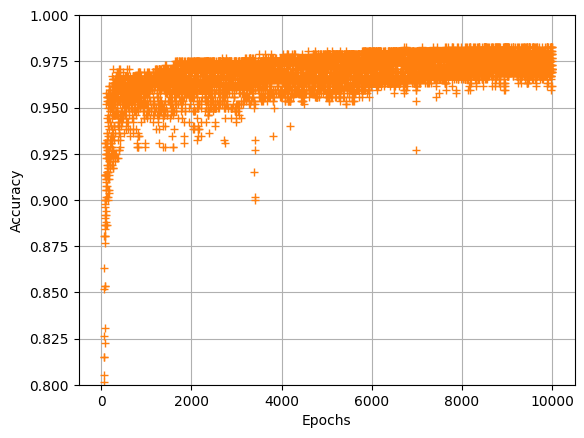

In [12]:
# acc = history.history['accuracy']
val_acc = np.array(history)[:,2]
epochs = range(1, len(val_acc) + 1)

# plt.plot(epochs, acc, 'b+')
plt.plot(epochs, val_acc, '+',color='tab:orange')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.ylim((0.8,1))
plt.grid()
plt.show()

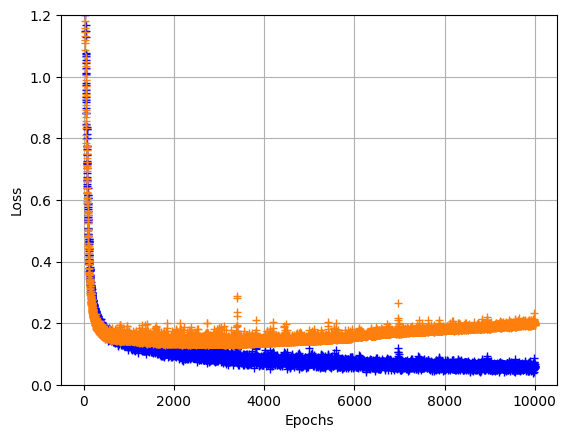

In [13]:
loss_values = np.array(history)[:,0]
val_loss_values = np.array(history)[:,1]
epochs = range(1, len(loss_values) + 1)

plt.plot(epochs, loss_values, 'b+')
plt.plot(epochs, val_loss_values, '+',color='tab:orange')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.ylim((0.,1.2))
plt.grid()
plt.show()

In [14]:
y_cv = model(torch.tensor(X_train, dtype=torch.float32)).detach().numpy()

In [15]:
new = np.zeros(y_cv.shape)
for i, j in enumerate(y_cv):
    new[i][np.argmax(j)] = 1

y_cv_class = new.astype('int')
y_cv_class

array([[1, 0, 0],
       [0, 0, 1],
       [1, 0, 0],
       ...,
       [1, 0, 0],
       [0, 1, 0],
       [1, 0, 0]])

In [16]:
# Calculate scores
r2_score_train = sklearn.metrics.r2_score(y_train, y_cv_class)
ev_score_train = sklearn.metrics.explained_variance_score(y_train, y_cv_class)
mse_train = sklearn.metrics.mean_squared_error(y_train, y_cv_class)
acc_score_train = sklearn.metrics.accuracy_score(y_train, y_cv_class)
precision_score_train_None = sklearn.metrics.precision_score(y_train, y_cv_class, average=None)
recall_score_train_None = sklearn.metrics.recall_score(y_train, y_cv_class, average=None)
precision_score_train_macro = sklearn.metrics.precision_score(y_train, y_cv_class, average='macro')
recall_score_train_macro= sklearn.metrics.recall_score(y_train, y_cv_class, average='macro')

print("R2 Score: {:.4f}".format(r2_score_train))
print("Explained variance score: {:.4f}".format(ev_score_train))
print("Mean squared error: {:.4f}".format(mse_train))
print("Accuracy Score: {:.4f}".format(acc_score_train))
print(f"Precision: {np.array2string(precision_score_train_None, precision=4, floatmode='fixed')}")
print(f"Recall: {np.array2string(recall_score_train_None, precision=4, floatmode='fixed')}")
print(f"Precision macro: {precision_score_train_macro}")
print(f"Recall macro: {recall_score_train_macro}")

R2 Score: 0.9458
Explained variance score: 0.9458
Mean squared error: 0.0089
Accuracy Score: 0.9867
Precision: [0.9859 0.9430 1.0000]
Recall: [0.9845 0.9729 0.9925]
Precision macro: 0.9762926945949736
Recall macro: 0.983279641331357


### Train quality

In [17]:
class_number = len(y_cv_class[0])
cm_train = np.zeros((class_number, class_number))
for tr, pre in zip(y_train, y_cv_class):
    i_true = np.argmax(tr)
    i_pred = np.argmax(pre)
    cm_train[i_true][i_pred] += 1
    
cm_train

array([[699.,  11.,   0.],
       [  6., 215.,   0.],
       [  4.,   2., 792.]])

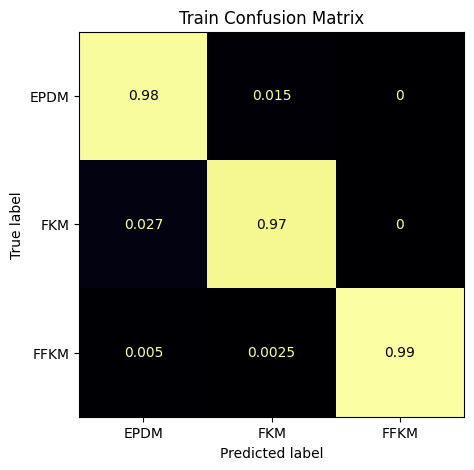

In [18]:
fig, ax = plt.subplots(1, 1, figsize=[5, 5])

disp = sklearn.metrics.ConfusionMatrixDisplay(np.array([cm_train[0] / cm_train[0].sum(), 
                                                        cm_train[1] / cm_train[1].sum(), 
                                                        cm_train[2] / cm_train[2].sum()]), 
                                              display_labels=['EPDM', 'FKM', 'FFKM'])

ax.set_title('Train Confusion Matrix')
disp.plot(cmap='inferno', ax=ax, colorbar=False) # cmap: https://matplotlib.org/stable/tutorials/colors/colormaps.html
plt.show()

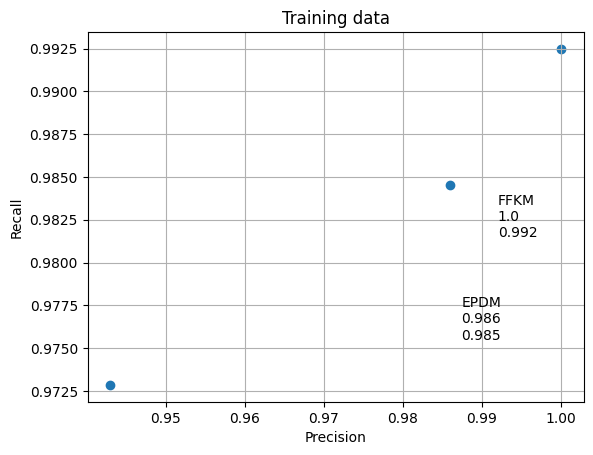

In [19]:
fig, ax = plt.subplots(1, 1)#, figsize=[5, 5])
n = ['EPDM\n'+str(round(precision_score_train_None[0],3))+'\n'+str(round(recall_score_train_None[0],3)),
     'FKM\n'+str(round(precision_score_train_None[1],3))+'\n'+str(round(recall_score_train_None[1],3)), 
     'FFKM\n'+str(round(precision_score_train_None[2],3))+'\n'+str(round(recall_score_train_None[2],3))]

ax.scatter(precision_score_train_None, recall_score_train_None)
ax.grid()
ax.set_xlabel('Precision')
ax.set_ylabel('Recall')
ax.set_title('Training data')

ax.annotate(n[0], (precision_score_train_None[0]+0.0015, recall_score_train_None[0]-0.009)) # EPDM
ax.annotate(n[1], (precision_score_train_None[1]+0.0015, recall_score_train_None[1]-0.003)) # FKM
ax.annotate(n[2], (precision_score_train_None[2]-0.008, recall_score_train_None[2]-0.011)) # FFKM
plt.show()

## Test model

In [20]:
y_predict = model(torch.tensor(X_test,dtype=torch.float32)).detach().numpy()
y_predict

array([[9.9997282e-01, 1.4582445e-05, 1.2611813e-05],
       [9.6198905e-01, 3.7724789e-02, 2.8616312e-04],
       [5.5907178e-04, 1.3925882e-07, 9.9944073e-01],
       ...,
       [5.1036040e-11, 1.0949845e-04, 9.9989045e-01],
       [2.5798838e-05, 9.9997389e-01, 3.5411850e-07],
       [5.7212530e-11, 5.7784735e-07, 9.9999940e-01]], dtype=float32)

### Test metrics

In [21]:
new = np.zeros(y_predict.shape)
for i, j in enumerate(y_predict): # enumerate, itterieren durch Liste i = index, j = Wert
    new[i][np.argmax(j)] = 1

y_predict_class = new.astype('int')
y_predict_class

array([[1, 0, 0],
       [1, 0, 0],
       [0, 0, 1],
       ...,
       [0, 0, 1],
       [0, 1, 0],
       [0, 0, 1]])

In [22]:
# Calculate scores
r2_score_test = sklearn.metrics.r2_score(y_test, y_predict_class)
ev_score_test = sklearn.metrics.explained_variance_score(y_test, y_predict_class)
mse_test = sklearn.metrics.mean_squared_error(y_test, y_predict_class)
acc_score_test = sklearn.metrics.accuracy_score(y_test, y_predict_class)
precision_score_test_None = sklearn.metrics.precision_score(y_test, y_predict_class, average=None)
recall_score_test_None = sklearn.metrics.recall_score(y_test, y_predict_class, average=None)
precision_score_test_macro = sklearn.metrics.precision_score(y_test, y_predict_class, average='macro')
recall_score_test_macro= sklearn.metrics.recall_score(y_test, y_predict_class, average='macro')

print("R2 Score: {:.4f}".format(r2_score_train))
print("Explained variance score: {:.4f}".format(ev_score_train))
print("Mean squared error: {:.4f}".format(mse_train))
print("Accuracy Score: {:.4f}".format(acc_score_test))
print(f"Precision: {np.array2string(precision_score_test_None, precision=4, floatmode='fixed')}")
print(f"Recall: {np.array2string(recall_score_test_None, precision=4, floatmode='fixed')}")
print(f"Precision macro: {precision_score_test_macro}")
print(f"Recall macro: {recall_score_test_macro}")

R2 Score: 0.9458
Explained variance score: 0.9458
Mean squared error: 0.0089
Accuracy Score: 0.9885
Precision: [0.9888 0.9348 1.0000]
Recall: [0.9888 0.9556 0.9952]
Precision macro: 0.9745364747793701
Recall macro: 0.9798658940675994


### Test quality

In [23]:
class_number = len(y_predict_class[0])
cm_test = np.zeros((class_number, class_number))
for tr, pre in zip(y_test, y_predict_class):
    i_true = np.argmax(tr)
    i_pred = np.argmax(pre)
    cm_test[i_true][i_pred] += 1
    
cm_test

array([[177.,   2.,   0.],
       [  2.,  43.,   0.],
       [  0.,   1., 208.]])

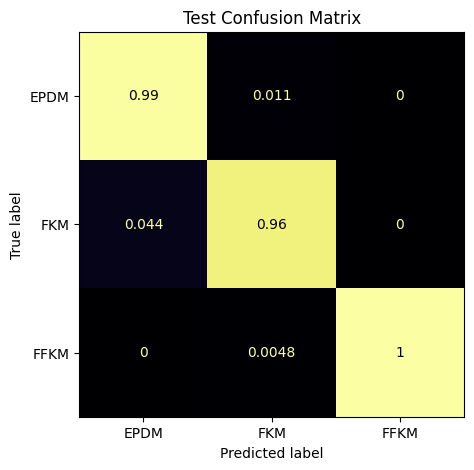

In [24]:
# sklearn.metrics.ConfusionMatrixDisplay(cm_train).plot()
fig, ax = plt.subplots(1, 1, figsize=[5, 5])

disp = sklearn.metrics.ConfusionMatrixDisplay(np.array([cm_test[0] / cm_test[0].sum(), 
                                                 cm_test[1] / cm_test[1].sum(), 
                                                 cm_test[2] / cm_test[2].sum()]),
                                              display_labels=['EPDM', 'FKM', 'FFKM'])

ax.set_title('Test Confusion Matrix')
disp.plot(cmap='inferno', ax=ax, colorbar=False) # cmap: https://matplotlib.org/stable/tutorials/colors/colormaps.html
plt.show()

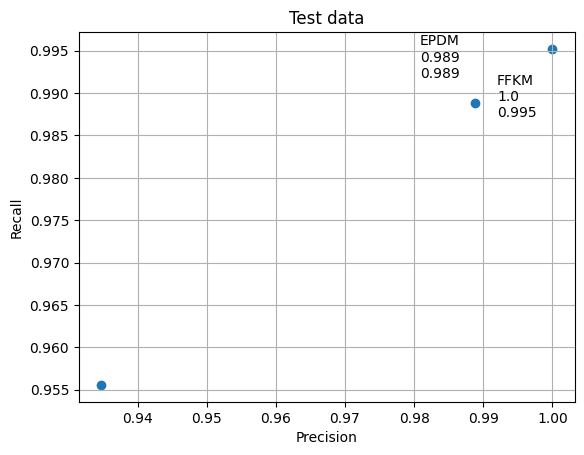

In [25]:
fig, ax = plt.subplots(1, 1)#, figsize=[5, 5])
n = ['EPDM\n'+str(round(precision_score_test_None[0],3))+'\n'+str(round(recall_score_test_None[0],3)),
     'FKM\n'+str(round(precision_score_test_None[1],3))+'\n'+str(round(recall_score_test_None[1],3)), 
     'FFKM\n'+str(round(precision_score_test_None[2],3))+'\n'+str(round(recall_score_test_None[2],3))]

ax.scatter(precision_score_test_None, recall_score_test_None)
ax.grid()
ax.set_xlabel('Precision')
ax.set_ylabel('Recall')
ax.set_title('Test data')

ax.annotate(n[0], (precision_score_test_None[0]-0.008, recall_score_test_None[0]+0.003)) # EPDM
ax.annotate(n[1], (precision_score_test_None[1]+0.0015, recall_score_test_None[1]-0.003)) # FKM
ax.annotate(n[2], (precision_score_test_None[2]-0.008, recall_score_test_None[2]-0.008)) # FFKM
plt.show()

In [27]:
# torch.save(deepcopy(model.state_dict()), 'UpsampleModel.pt')